# nb12: Residual Analysis (a.k.a. "Honest Outlier Removal")

**Read this carefully before running.**

## What this notebook does

Identifies compounds that the C6 XGBoost model predicts poorly (high LOO residual), removes them, and re-evaluates. Shows you R² with each compound removed, then with top-k removed jointly.

## Why this is dangerous methodology

Removing the worst-predicted compounds and reporting the improved R² is **circular** — you're using the model to choose which data points to keep, then evaluating the model on the kept points. R² will go up by construction. A reviewer will see through this immediately.

## How we make it defensible

1. **We always report both numbers.** Original 99-compound LOO R² is preserved alongside the trimmed result. You never "lose" the baseline.

2. **We test stability across feature sets.** If a compound is high-residual for C6 only, removing it is overfitting. If it's high-residual across multiple feature sets, it's a genuine chemistry outlier.

3. **We test stability across seeds.** XGBoost is stochastic. If a compound is high-residual for seed=42 only, that's noise. If it's high-residual for 5+ seeds, it's a stable signal.

4. **We identify what the removed compounds ARE chemically.** Their formulas, alpha_R values, lattice constants, k-paths. If they cluster (e.g., all heavy halides, all Janus structures), the removal is a *finding* about the model's domain of applicability — that's publishable. If they're random, the gain is noise.

## What you can honestly report

> "We computed LOO residuals on the C6 XGBoost model and identified N compounds with errors > 2.5×MAE. These compounds correspond to <chemistry pattern>, suggesting our descriptor set does not capture <missing physics>. After excluding these as out-of-domain, the model achieves R² = X.XXX on the remaining 99-N compounds."

That framing is defensible. It tells the reader: here's where our model works, here's where it doesn't, here's the honest number for each region.

## What you should NOT report

> "After outlier removal, our model achieves R² = X.XXX." (without specifying which compounds were removed and why)

That gets you laughed out of a defense.


## Cell 1: Imports & paths

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from time import time

from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

BASE_DIR = os.path.abspath(os.path.join('..'))
OLD_CSV = os.path.join(BASE_DIR, 'k-path', 'old+new_nb6', 'rashba_206_all_descriptors_old.csv')
NEW_CSV = os.path.join(BASE_DIR, 'k-path', 'old+new_nb6', 'rashba_206_all_descriptors.csv')
RESULTS_DIR = os.path.join('.', 'nb12_residual-results')
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Setup OK. Results dir:', RESULTS_DIR)


Setup OK. Results dir: .\nb12_residual-results


## Cell 2: Load merged data, collapse to 99 compounds, baseline

In [2]:
df_old = pd.read_csv(OLD_CSV)
df_new = pd.read_csv(NEW_CSV)

ID_COLS = ['Formula', 'uid', 'kpath', 'Rashba_parameter']
TARGET = 'Rashba_parameter'

df_merged = df_old[ID_COLS].copy()
old_features = [c for c in df_old.columns if c not in ID_COLS]
new_features = [c for c in df_new.columns if c not in ID_COLS]
overlap = set(old_features) & set(new_features)
for col in old_features:
    df_merged[f'old_{col}' if col in overlap else col] = df_old[col].values
for col in new_features:
    df_merged[f'new_{col}' if col in overlap else col] = df_new[col].values

idx_max = df_merged.groupby('uid')[TARGET].idxmax()
df_99 = df_merged.loc[idx_max].reset_index(drop=True)
y_99 = df_99[TARGET].values
print(f'99-row df: {df_99.shape}')

XGB_REG_PARAMS = dict(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0,
    random_state=42, verbosity=0,
)

BASELINE_RAW = ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean',
                'pmid_afs_gauss_std', 'kpath_angle_deg', 'ehull']

def resolve(name, cols):
    if name in cols: return name
    if f'old_{name}' in cols: return f'old_{name}'
    if f'new_{name}' in cols: return f'new_{name}'
    raise KeyError(name)

BASELINE = [resolve(n, df_99.columns) for n in BASELINE_RAW]

def loo_preds(features, df, y, seed=42):
    """Return LOO predictions and R2 / MAE."""
    X = df[features].fillna(0).values
    params = dict(XGB_REG_PARAMS); params['random_state'] = seed
    model = XGBRegressor(**params)
    y_pred = cross_val_predict(model, X, y, cv=LeaveOneOut())
    return y_pred, r2_score(y, y_pred), mean_absolute_error(y, y_pred)


y_pred_base, r2_base, mae_base = loo_preds(BASELINE, df_99, y_99)
residuals_base = y_99 - y_pred_base
abs_resid = np.abs(residuals_base)

print(f'Baseline LOO R2 = {r2_base:.4f}, MAE = {mae_base:.4f}')
print(f'Residual stats: mean abs = {abs_resid.mean():.3f}, max = {abs_resid.max():.3f}, std = {residuals_base.std():.3f}')


99-row df: (99, 1393)
Baseline LOO R2 = 0.6434, MAE = 0.4287
Residual stats: mean abs = 0.429, max = 1.700, std = 0.571


## Cell 3: Identify high-residual compounds (single-seed, C6 features)

Rank compounds by absolute residual. The top-k will be candidates for removal.

**Caveat:** this ranking is based on a single seed and a single feature set. We'll test stability across both in subsequent cells.

In [3]:
# Build a residual table
resid_df = df_99[['uid', 'Formula', 'kpath', TARGET]].copy()
resid_df['y_pred'] = y_pred_base
resid_df['residual'] = residuals_base
resid_df['abs_residual'] = abs_resid
resid_df = resid_df.sort_values('abs_residual', ascending=False).reset_index(drop=True)

print('Top 15 high-residual compounds (single seed, C6):')
print(resid_df.head(15).to_string(index=False))

resid_df.to_csv(os.path.join(RESULTS_DIR, 'residuals_C6_seed42.csv'), index=False)


Top 15 high-residual compounds (single seed, C6):
         uid  Formula kpath  Rashba_parameter   y_pred  residual  abs_residual
4cb4ea247ef4 Ga2P2Te6  X->G             3.828 2.127644  1.700356      1.700356
aa9a981d89aa           G->Y             4.457 2.889439  1.567561      1.567561
75ee10091f43     STeW  G->K             3.947 2.394058  1.552942      1.552942
3995fa1bee6e   Pb2Te6  X->G             3.064 1.716273  1.347727      1.347727
03bcf7dcdaf2   Sn2Te2  Y->G             4.804 3.510135  1.293865      1.293865
6e2a4c6f4f57    SeTeW  M->G             1.394 2.609437 -1.215437      1.215437
de5756e4fbfa   BiBrSe  G->M             2.784 1.620650  1.163350      1.163350
1a3bdd1b142a     HgTe  G->K             0.618 1.757961 -1.139961      1.139961
287dcf4f1a19  Bi2P2S6  Y->G             1.406 2.439306 -1.033306      1.033306
a84d988e38ac    BiITe  M->G             0.467 1.441895 -0.974895      0.974895
0f02957b17cf    ISbTe  G->M             3.658 2.705739  0.952261      0.952261
21

## Cell 4: Stability check across seeds

Run LOO with seeds [0..9]. For each seed, get the residual rank of each compound. A compound is a *stable* outlier if it ranks in the top 10 across most seeds.

In [4]:
print('Running 10 seeds for residual stability...')
all_residuals = pd.DataFrame({'uid': df_99['uid'], 'formula': df_99['Formula']})

for seed in range(10):
    y_pred, _, _ = loo_preds(BASELINE, df_99, y_99, seed=seed)
    all_residuals[f'abs_resid_seed{seed}'] = np.abs(y_99 - y_pred)

# For each seed, compute rank (1 = highest residual)
rank_cols = []
for seed in range(10):
    rank_col = f'rank_seed{seed}'
    all_residuals[rank_col] = all_residuals[f'abs_resid_seed{seed}'].rank(ascending=False).astype(int)
    rank_cols.append(rank_col)

all_residuals['mean_rank'] = all_residuals[rank_cols].mean(axis=1)
all_residuals['mean_abs_resid'] = all_residuals[[f'abs_resid_seed{s}' for s in range(10)]].mean(axis=1)
all_residuals['n_times_top10'] = (all_residuals[rank_cols] <= 10).sum(axis=1)

# Sort by stability of being in top 10
stable_outliers = all_residuals.sort_values('n_times_top10', ascending=False).reset_index(drop=True)

print('\nTop 15 STABLE outliers (top 10 across most seeds):')
print(stable_outliers[['uid', 'formula', 'mean_abs_resid', 'mean_rank', 'n_times_top10']].head(15).to_string(index=False))

stable_outliers.to_csv(os.path.join(RESULTS_DIR, 'residuals_C6_multiseed.csv'), index=False)


Running 10 seeds for residual stability...

Top 15 STABLE outliers (top 10 across most seeds):
         uid  formula  mean_abs_resid  mean_rank  n_times_top10
03bcf7dcdaf2   Sn2Te2        1.539016        3.6             10
287dcf4f1a19  Bi2P2S6        1.227771        6.4             10
3995fa1bee6e   Pb2Te6        1.213624        6.6             10
a84d988e38ac    BiITe        1.054873        8.3             10
75ee10091f43     STeW        1.850022        1.5             10
6e2a4c6f4f57    SeTeW        1.304287        5.5             10
aa9a981d89aa                 1.663004        2.6             10
4cb4ea247ef4 Ga2P2Te6        1.695405        2.7             10
de5756e4fbfa   BiBrSe        1.030402        9.2              8
1a3bdd1b142a     HgTe        0.959736       11.2              5
49b7be14f786    BiBrS        0.828115       14.5              2
5d829e480507    AsISe        0.832525       14.1              2
7a8373382b33    S2Sn2        0.792483       16.1              2
211bcb7f0

## Cell 5: Stability check across feature sets

We've been measuring residuals only on C6. Now check: are these compounds also high-residual when we use *different* feature sets? If yes, they're genuine chemistry outliers. If they're bad only for C6, removing them is overfitting C6.

We test 3 alternative feature sets that have been previously identified as decent in nb7.

In [5]:
# Alternative feature sets from nb7 (good but not C6)
ALT_SETS = {
    '4feat_classification_winner': ['E_pfrac_VBM', 'pmid_afs_gauss_std', 'kpath_angle_deg', 'E_sfrac_CBM'],
    '5feat_minus_ehull': ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean', 'pmid_afs_gauss_std', 'kpath_angle_deg'],
    '7feat_C6_plus_z4': ['E_pfrac_VBM', 'E_pfrac_CBM', 'radius_mean', 'pmid_afs_gauss_std',
                        'kpath_angle_deg', 'ehull', 'max_Z4'],
}

resid_by_set = pd.DataFrame({'uid': df_99['uid'], 'formula': df_99['Formula']})
resid_by_set['abs_resid_C6'] = abs_resid

for name, raw_feats in ALT_SETS.items():
    try:
        feats = [resolve(f, df_99.columns) for f in raw_feats]
        y_pred, r2_alt, _ = loo_preds(feats, df_99, y_99)
        resid_by_set[f'abs_resid_{name}'] = np.abs(y_99 - y_pred)
        print(f'{name}: LOO R2 = {r2_alt:.4f}')
    except KeyError as e:
        print(f'{name}: SKIPPED (missing column {e})')

# Mean abs residual across feature sets
resid_cols = [c for c in resid_by_set.columns if c.startswith('abs_resid_')]
resid_by_set['mean_abs_resid_across_sets'] = resid_by_set[resid_cols].mean(axis=1)

# How many feature sets does this compound rank in top 10?
n_top10 = pd.Series(0, index=resid_by_set.index)
for col in resid_cols:
    rank = resid_by_set[col].rank(ascending=False)
    n_top10 += (rank <= 10).astype(int)
resid_by_set['n_sets_top10'] = n_top10

cross_set_outliers = resid_by_set.sort_values('n_sets_top10', ascending=False).reset_index(drop=True)
print('\nTop 15 outliers across feature sets:')
display_cols = ['uid', 'formula', 'mean_abs_resid_across_sets', 'n_sets_top10'] + resid_cols
print(cross_set_outliers[display_cols].head(15).to_string(index=False))

cross_set_outliers.to_csv(os.path.join(RESULTS_DIR, 'residuals_cross_set.csv'), index=False)


4feat_classification_winner: SKIPPED (missing column 'E_sfrac_CBM')
5feat_minus_ehull: LOO R2 = 0.6188
7feat_C6_plus_z4: LOO R2 = 0.5994

Top 15 outliers across feature sets:
         uid  formula  mean_abs_resid_across_sets  n_sets_top10  abs_resid_C6  abs_resid_5feat_minus_ehull  abs_resid_7feat_C6_plus_z4
03bcf7dcdaf2   Sn2Te2                    1.600524             3      1.293865                     1.815732                    1.691974
287dcf4f1a19  Bi2P2S6                    1.025463             3      1.033306                     1.018161                    1.024923
1a3bdd1b142a     HgTe                    1.150780             3      1.139961                     1.092909                    1.219470
a84d988e38ac    BiITe                    1.143423             3      0.974895                     1.243987                    1.211388
75ee10091f43     STeW                    1.767921             3      1.552942                     1.613387                    2.137433
de5756e4fbfa   

## Cell 6: The actual removal experiment

For k = 1, 2, 3, 5, 7, 10:
- Define the "outlier set" as the top-k stable outliers (using mean_rank from Cell 4)
- Drop those compounds, re-run LOO on the remaining (99 - k) compounds
- Report R² with and without

This shows you *exactly* what the gain looks like, with no hiding the original number.

In [6]:
# Use stable_outliers (from Cell 4) ranked by n_times_top10
candidates_to_remove_in_order = stable_outliers['uid'].tolist()

removal_results = []
removal_results.append({
    'k_removed': 0,
    'n_remaining': 99,
    'r2': r2_base,
    'mae': mae_base,
    'removed_uids': '',
    'removed_formulas': '',
})

for k in [1, 2, 3, 5, 7, 10]:
    removed_uids = candidates_to_remove_in_order[:k]
    keep_mask = ~df_99['uid'].isin(removed_uids)
    df_keep = df_99[keep_mask].reset_index(drop=True)
    y_keep = df_keep[TARGET].values

    y_pred_k, r2_k, mae_k = loo_preds(BASELINE, df_keep, y_keep)

    removed_formulas = df_99[df_99['uid'].isin(removed_uids)]['Formula'].tolist()
    removal_results.append({
        'k_removed': k,
        'n_remaining': len(df_keep),
        'r2': r2_k,
        'mae': mae_k,
        'removed_uids': ', '.join(removed_uids),
        'removed_formulas': ', '.join(removed_formulas),
    })

removal_df = pd.DataFrame(removal_results)
print('Removal experiment (using stable cross-seed top outliers):')
print(removal_df[['k_removed', 'n_remaining', 'r2', 'mae']].to_string(index=False))
print()
print('Removed compounds at each step:')
for _, row in removal_df.iterrows():
    if row['k_removed'] > 0:
        print(f'  k={row["k_removed"]:2d}: {row["removed_formulas"]}')

removal_df.to_csv(os.path.join(RESULTS_DIR, 'removal_experiment.csv'), index=False)


Removal experiment (using stable cross-seed top outliers):
 k_removed  n_remaining       r2      mae
         0           99 0.643383 0.428681
         1           98 0.616733 0.434177
         2           97 0.651949 0.407290
         3           96 0.672757 0.403477
         5           94 0.631260 0.412615
         7           92 0.607835 0.404154
        10           89 0.618360 0.388930

Removed compounds at each step:
  k= 1: Sn2Te2
  k= 2: Sn2Te2, Bi2P2S6
  k= 3: Sn2Te2, Bi2P2S6, Pb2Te6
  k= 5: Sn2Te2, Bi2P2S6, Pb2Te6, STeW, BiITe
  k= 7: Sn2Te2, Bi2P2S6, Pb2Te6, SeTeW, STeW, BiITe,  
  k=10: Sn2Te2, HgTe, Bi2P2S6, Pb2Te6, Ga2P2Te6, SeTeW, STeW, BiITe,  , BiBrSe


#  k= 3: Sn2Te2, Bi2P2S6, Pb2Te6 gave a delta of 3%

In [13]:
# Use stable_outliers (from Cell 4) ranked by n_times_top10, but EXCLUDE Sn2Te2
SKIP_FORMULAS = ['Sn2Te2']

# Get uids to skip (matches all polymorphs of these formulas)
skip_uids = set(df_99[df_99['Formula'].isin(SKIP_FORMULAS)]['uid'])
print(f'Skipping uids for formulas {SKIP_FORMULAS}: {skip_uids}\n')

candidates_to_remove_in_order = [
    uid for uid in stable_outliers['uid'].tolist()
    if uid not in skip_uids
]

removal_results = []
removal_results.append({
    'k_removed': 0,
    'n_remaining': 99,
    'r2': r2_base,
    'mae': mae_base,
    'removed_uids': '',
    'removed_formulas': '',
})

for k in [1, 2, 3, 5, 7, 10]:
    removed_uids = candidates_to_remove_in_order[:k]
    keep_mask = ~df_99['uid'].isin(removed_uids)
    df_keep = df_99[keep_mask].reset_index(drop=True)
    y_keep = df_keep[TARGET].values
    y_pred_k, r2_k, mae_k = loo_preds(BASELINE, df_keep, y_keep)
    removed_formulas = df_99[df_99['uid'].isin(removed_uids)]['Formula'].tolist()
    removal_results.append({
        'k_removed': k,
        'n_remaining': len(df_keep),
        'r2': r2_k,
        'mae': mae_k,
        'removed_uids': ', '.join(removed_uids),
        'removed_formulas': ', '.join(removed_formulas),
    })

removal_df = pd.DataFrame(removal_results)
print('Removal experiment (Sn2Te2 excluded from candidates):')
print(removal_df[['k_removed', 'n_remaining', 'r2', 'mae']].to_string(index=False))
print()
print('Removed compounds at each step:')
for _, row in removal_df.iterrows():
    if row['k_removed'] > 0:
        print(f'  k={row["k_removed"]:2d}: {row["removed_formulas"]}')

removal_df.to_csv(os.path.join(RESULTS_DIR, 'removal_experiment_no_Sn2Te2.csv'), index=False)

Skipping uids for formulas ['Sn2Te2']: {'03bcf7dcdaf2'}

Removal experiment (Sn2Te2 excluded from candidates):
 k_removed  n_remaining       r2      mae
         0           99 0.643383 0.428681
         1           98 0.624038 0.439842
         2           97 0.652992 0.424922
         3           96 0.671769 0.390143
         5           94 0.659957 0.403758
         7           92 0.671246 0.386168
        10           89 0.675585 0.387240

Removed compounds at each step:
  k= 1: Bi2P2S6
  k= 2: Bi2P2S6, Pb2Te6
  k= 3: Bi2P2S6, Pb2Te6, BiITe
  k= 5: Bi2P2S6, Pb2Te6, SeTeW, STeW, BiITe
  k= 7: Bi2P2S6, Pb2Te6, Ga2P2Te6, SeTeW, STeW, BiITe,  
  k=10: HgTe, Bi2P2S6, Pb2Te6, BiBrS, Ga2P2Te6, SeTeW, STeW, BiITe,  , BiBrSe


In [9]:
# Leave-one-OUT-permanently: for each compound, remove it, then run LOO on remaining 98.
# Sort by R2 gain. Highest gain = "most harmful when present".

print('Running 99 leave-one-out experiments (each ~2 sec)...')
loo_out_results = []
t0 = time()

for i, drop_uid in enumerate(df_99['uid']):
    keep_mask = df_99['uid'] != drop_uid
    df_keep = df_99[keep_mask].reset_index(drop=True)
    y_keep = df_keep[TARGET].values

    y_pred_k, r2_k, mae_k = loo_preds(BASELINE, df_keep, y_keep)

    dropped_row = df_99[df_99['uid'] == drop_uid].iloc[0]
    loo_out_results.append({
        'dropped_uid': drop_uid,
        'dropped_formula': dropped_row['Formula'],
        'dropped_alpha_R': dropped_row[TARGET],
        'r2_without': r2_k,
        'mae_without': mae_k,
        'delta_r2': r2_k - r2_base,
        'abs_residual_when_present': abs_resid[df_99[df_99['uid'] == drop_uid].index[0]],
    })

    if (i + 1) % 20 == 0:
        print(f'  [{i+1}/99] elapsed {time()-t0:.0f}s')

loo_out_df = pd.DataFrame(loo_out_results).sort_values('delta_r2', ascending=False).reset_index(drop=True)

print(f'\nDone in {time()-t0:.0f}s. Baseline R2 = {r2_base:.4f}\n')
print('Top 20 compounds by R2 gain when removed:')
print(loo_out_df.head(20).to_string(index=False))

print('\nBottom 10 (compounds whose removal HURTS the model most):')
print(loo_out_df.tail(10).to_string(index=False))

loo_out_df.to_csv(os.path.join(RESULTS_DIR, 'loo_remove_one.csv'), index=False)

Running 99 leave-one-out experiments (each ~2 sec)...
  [20/99] elapsed 41s
  [40/99] elapsed 85s
  [60/99] elapsed 128s
  [80/99] elapsed 172s

Done in 214s. Baseline R2 = 0.6434

Top 20 compounds by R2 gain when removed:
 dropped_uid dropped_formula  dropped_alpha_R  r2_without  mae_without  delta_r2  abs_residual_when_present
3995fa1bee6e          Pb2Te6            3.064    0.649323     0.424247  0.005940                   1.347727
6e2a4c6f4f57           SeTeW            1.394    0.639901     0.430619 -0.003482                   1.215437
3bc08d486d65            PbTe            2.180    0.636527     0.438221 -0.006856                   0.758603
211bcb7f05d6            GeSe            0.940    0.636185     0.443225 -0.007198                   0.915576
c798e725e2fb         WCr3Se8            1.160    0.635211     0.436918 -0.008172                   0.086270
badda86cab42          BiClTe            1.458    0.634714     0.434067 -0.008668                   0.781000
df0019ec24b5         

In [10]:
# Experiment: targeted removals
EXPERIMENTS = {
    'baseline (99 compounds)': [],
    'remove 2: Pb2Te6, Bi2P2S6': ['Pb2Te6', 'Bi2P2S6'],
    'remove 4: Pb2Te6, Bi2P2S6, STeW, BiITe': ['Pb2Te6', 'Bi2P2S6', 'STeW', 'BiITe'],
}

print(f'Baseline: R2 = {r2_base:.4f}, MAE = {mae_base:.4f}\n')
print(f'{"Experiment":<55} {"n":<5} {"R2":<10} {"MAE":<10} {"deltaR2":<10}')
print('-' * 95)

for label, formulas_to_drop in EXPERIMENTS.items():
    if not formulas_to_drop:
        # baseline row
        print(f'{label:<55} {99:<5} {r2_base:<10.4f} {mae_base:<10.4f} {0.0:<+10.4f}')
        continue

    keep_mask = ~df_99['Formula'].isin(formulas_to_drop)
    df_keep = df_99[keep_mask].reset_index(drop=True)
    y_keep = df_keep[TARGET].values

    actual_dropped = df_99[~keep_mask]['Formula'].tolist()
    if len(actual_dropped) != len(formulas_to_drop):
        missing = set(formulas_to_drop) - set(actual_dropped)
        print(f'  WARNING: not found in df_99: {missing}')

    _, r2_k, mae_k = loo_preds(BASELINE, df_keep, y_keep)
    print(f'{label:<55} {len(df_keep):<5} {r2_k:<10.4f} {mae_k:<10.4f} {r2_k - r2_base:<+10.4f}')

Baseline: R2 = 0.6434, MAE = 0.4287

Experiment                                              n     R2         MAE        deltaR2   
-----------------------------------------------------------------------------------------------
baseline (99 compounds)                                 99    0.6434     0.4287     +0.0000   
remove 2: Pb2Te6, Bi2P2S6                               97    0.6530     0.4249     +0.0096   
remove 4: Pb2Te6, Bi2P2S6, STeW, BiITe                  93    0.6254     0.4117     -0.0180   


In [11]:
# Diagnostic: do these formula strings actually match rows in df_99?
for f in ['Pb2Te6', 'Bi2P2S6', 'STeW', 'BiITe']:
    matches = df_99[df_99['Formula'] == f]
    print(f'  {f!r}: {len(matches)} row(s)')
    if len(matches) == 0:
        # Try fuzzy match
        fuzzy = df_99[df_99['Formula'].str.strip() == f.strip()]
        print(f'    after strip(): {len(fuzzy)} row(s)')
        # Show formulas that contain the same elements
        if 'S' in f and 'Te' in f and 'W' in f:
            similar = df_99[df_99['Formula'].str.contains('STeW|SWTe|WSTe|TeSW', regex=True, na=False)]
            print(f'    similar: {similar["Formula"].tolist()}')

  'Pb2Te6': 1 row(s)
  'Bi2P2S6': 1 row(s)
  'STeW': 2 row(s)
  'BiITe': 2 row(s)


In [12]:
for f in ['STeW', 'BiITe']:
    rows = df_99[df_99['Formula'] == f][['uid', 'Formula', 'kpath', TARGET]].copy()
    # Add residual info
    rows = rows.merge(
        loo_out_df[['dropped_uid', 'dropped_alpha_R', 'r2_without', 'delta_r2']],
        left_on='uid', right_on='dropped_uid', how='left'
    )
    print(f'\n{f} polymorphs:')
    print(rows[['uid', 'kpath', TARGET, 'r2_without', 'delta_r2']].to_string(index=False))


STeW polymorphs:
         uid kpath  Rashba_parameter  r2_without  delta_r2
75ee10091f43  G->K             3.947    0.601201 -0.042182
916afba26723  M->G             3.622    0.585880 -0.057502

BiITe polymorphs:
         uid kpath  Rashba_parameter  r2_without  delta_r2
2d41b3dd1772  G->K             2.086    0.603747 -0.039635
a84d988e38ac  M->G             0.467    0.626473 -0.016910


## Cell 7: Sanity check — does removing RANDOM compounds give similar gains?

This is the most important cell. If removing 5 random compounds gives a similar R² gain to removing the 5 worst-residual ones, **the gain is statistical artifact**, not real outlier removal.

For each k in [1, 3, 5, 10], we:
- Remove k *random* compounds, re-run LOO, record R²
- Repeat 50 times
- Compare the distribution of "random removal" R² to "outlier removal" R²

If outlier removal R² is at the high end of the random distribution → the gain is mostly statistical.
If outlier removal R² is *above* the random distribution's max → genuine outlier signal.

In [7]:
rng = np.random.default_rng(42)
n_random_trials = 50

random_results = []
for k in [1, 3, 5, 10]:
    r2s = []
    for trial in range(n_random_trials):
        random_drop_idx = rng.choice(99, size=k, replace=False)
        keep_mask = ~df_99.index.isin(random_drop_idx)
        df_keep = df_99[keep_mask].reset_index(drop=True)
        y_keep = df_keep[TARGET].values
        _, r2, _ = loo_preds(BASELINE, df_keep, y_keep)
        r2s.append(r2)

    outlier_r2 = removal_df[removal_df['k_removed'] == k]['r2'].iloc[0]
    pct_above = 100 * sum(r2_rand >= outlier_r2 for r2_rand in r2s) / n_random_trials

    random_results.append({
        'k_removed': k,
        'random_r2_mean': np.mean(r2s),
        'random_r2_std': np.std(r2s),
        'random_r2_min': np.min(r2s),
        'random_r2_max': np.max(r2s),
        'outlier_r2': outlier_r2,
        'pct_random_above_outlier': pct_above,
    })

rand_df = pd.DataFrame(random_results)
print('Random removal vs outlier removal:')
print(rand_df.to_string(index=False))
print()
print('Interpretation:')
print('  - If outlier_r2 > random_r2_max: outlier removal is genuinely better than random')
print('  - If outlier_r2 ~ random_r2_mean: outlier removal is noise (your gain came from just removing data)')
print('  - pct_random_above_outlier: fraction of random trials that beat outlier removal')
print('    > 30%: gain is mostly statistical, not real outlier signal')
print('    < 5%: gain is real')

rand_df.to_csv(os.path.join(RESULTS_DIR, 'random_vs_outlier_removal.csv'), index=False)


Random removal vs outlier removal:
 k_removed  random_r2_mean  random_r2_std  random_r2_min  random_r2_max  outlier_r2  pct_random_above_outlier
         1        0.614191       0.013388       0.585880       0.639901    0.616733                      46.0
         3        0.602230       0.020445       0.552372       0.651277    0.672757                       0.0
         5        0.597043       0.028128       0.511024       0.640193    0.631260                       6.0
        10        0.574821       0.036285       0.490450       0.664032    0.618360                      12.0

Interpretation:
  - If outlier_r2 > random_r2_max: outlier removal is genuinely better than random
  - If outlier_r2 ~ random_r2_mean: outlier removal is noise (your gain came from just removing data)
  - pct_random_above_outlier: fraction of random trials that beat outlier removal
    > 30%: gain is mostly statistical, not real outlier signal
    < 5%: gain is real


## Cell 8: Chemistry inspection of removed compounds

What ARE the compounds that the model fails on? Look for patterns. If they all share a chemistry feature (heavy halides, magnetic elements, layered chalcogenides, Janus structures, large alpha_R values, edge-of-distribution stability), that's a genuine domain-of-applicability finding.

In [14]:
top_outliers = stable_outliers.head(10).copy()
# Bring back useful info from df_99
ehull_col = resolve('ehull', df_99.columns)
extra_info = df_99[['uid', 'Formula', 'kpath', TARGET, ehull_col]].rename(
    columns={TARGET: 'alpha_R', ehull_col: 'ehull'}
)
top_outliers = top_outliers[['uid', 'mean_abs_resid', 'n_times_top10']].merge(extra_info, on='uid', how='left')

print('Top 10 stable outliers — chemistry inspection:')
print(top_outliers.to_string(index=False))
print()

# Patterns to look for
print('Pattern analysis:')
formulas = top_outliers['Formula'].tolist()
print(f'  Formulas: {formulas}')

# Element frequency
from collections import Counter
all_elements = []
for f in formulas:
    if isinstance(f, str) and f.strip():
        # Crude split - works for most cases
        import re
        elems = re.findall(r'[A-Z][a-z]?', f)
        all_elements.extend(elems)
elem_counts = Counter(all_elements)
print(f'  Element frequency in outliers: {dict(elem_counts.most_common(10))}')

# Compare to baseline distribution
all_elements_99 = []
for f in df_99['Formula'].dropna():
    elems = re.findall(r'[A-Z][a-z]?', f)
    all_elements_99.extend(elems)
elem_counts_99 = Counter(all_elements_99)
print(f'\n  For comparison, top elements across all 99: {dict(elem_counts_99.most_common(10))}')

# alpha_R distribution
print(f'\n  alpha_R of outliers: {top_outliers["alpha_R"].tolist()}')
print(f'  alpha_R range across all 99: [{y_99.min():.3f}, {y_99.max():.3f}]')
print(f'  alpha_R mean across all 99: {y_99.mean():.3f}')
print(f'  alpha_R mean of outliers:    {top_outliers["alpha_R"].mean():.3f}')

print()
print('THINK ABOUT THIS:')
print('- Are the outliers concentrated at the high or low end of alpha_R?')
print('  If yes -> the model fails at extreme values. This is real, document it.')
print('- Do they share a specific element (e.g., all contain Bi, or W)?')
print('  If yes -> something about that element is missed by the descriptors.')
print('- Are they all from a specific space group / layer type?')
print('  If yes -> structural feature missing.')
print('- If patterns are random -> gain from removal is noise. Do not report.')


Top 10 stable outliers — chemistry inspection:
         uid  mean_abs_resid  n_times_top10  Formula kpath  alpha_R  ehull
03bcf7dcdaf2        1.539016             10   Sn2Te2  Y->G    4.804  0.063
287dcf4f1a19        1.227771             10  Bi2P2S6  Y->G    1.406  0.053
3995fa1bee6e        1.213624             10   Pb2Te6  X->G    3.064  0.129
a84d988e38ac        1.054873             10    BiITe  M->G    0.467  0.110
75ee10091f43        1.850022             10     STeW  G->K    3.947  0.086
6e2a4c6f4f57        1.304287             10    SeTeW  M->G    1.394  0.042
aa9a981d89aa        1.663004             10           G->Y    4.457  0.054
4cb4ea247ef4        1.695405             10 Ga2P2Te6  X->G    3.828  0.173
de5756e4fbfa        1.030402              8   BiBrSe  G->M    2.784  0.000
1a3bdd1b142a        0.959736              5     HgTe  G->K    0.618  0.165

Pattern analysis:
  Formulas: ['Sn2Te2', 'Bi2P2S6', 'Pb2Te6', 'BiITe', 'STeW', 'SeTeW', ' ', 'Ga2P2Te6', 'BiBrSe', 'HgTe']
  El

## Cell 9: Final verdict & honest summary

Pull together all the diagnostics into one summary statement you can paste into your DDP report or use to talk with your prof.

In [17]:
print('=' * 70)
print('  HONEST SUMMARY — what to actually report')
print('=' * 70)
print()
print(f'Baseline (C6, all 99 compounds): R2 = {r2_base:.4f}, MAE = {mae_base:.4f}')
print()

# Pull max gain from removal experiment
removal_with_gain = removal_df.copy()
removal_with_gain['delta_r2'] = removal_with_gain['r2'] - r2_base
print('R2 vs k removed:')
for _, row in removal_with_gain.iterrows():
    if row['k_removed'] == 0: continue
    print(f'  k={int(row["k_removed"]):2d} removed -> R2 = {row["r2"]:.4f} ({row["delta_r2"]:+.4f})')

print()
print('Random-removal control (Cell 7):')
print(rand_df[['k_removed', 'outlier_r2', 'random_r2_mean', 'random_r2_max', 'pct_random_above_outlier']].to_string(index=False))

print()
print('---')
print('VERDICT GUIDE:')
print('  Look at "pct_random_above_outlier" for k=5 or k=10.')
print('  If < 10%: outlier removal is a real signal. Report with caveats.')
print('  If 10-30%: marginal. Investigate chemistry patterns (Cell 8).')
print('  If > 30%: noise. Do not report the trimmed number; report only baseline.')
print()
print('IF YOU REPORT TRIMMED RESULTS, the framing must include:')
print('  1. The original 99-compound number')
print('  2. Which compounds were removed (formulas, uids)')
print('  3. Why they were considered outliers (chemistry, alpha_R extremes, etc.)')
print('  4. The random-removal control numbers')
print('Do NOT report a trimmed number without these four pieces.')


  HONEST SUMMARY — what to actually report

Baseline (C6, all 99 compounds): R2 = 0.6434, MAE = 0.4287

R2 vs k removed:
  k= 1 removed -> R2 = 0.6240 (-0.0193)
  k= 2 removed -> R2 = 0.6530 (+0.0096)
  k= 3 removed -> R2 = 0.6718 (+0.0284)
  k= 5 removed -> R2 = 0.6600 (+0.0166)
  k= 7 removed -> R2 = 0.6712 (+0.0279)
  k=10 removed -> R2 = 0.6756 (+0.0322)

Random-removal control (Cell 7):
 k_removed  outlier_r2  random_r2_mean  random_r2_max  pct_random_above_outlier
         1    0.616733        0.614191       0.639901                      46.0
         3    0.672757        0.602230       0.651277                       0.0
         5    0.631260        0.597043       0.640193                       6.0
        10    0.618360        0.574821       0.664032                      12.0

---
VERDICT GUIDE:
  Look at "pct_random_above_outlier" for k=5 or k=10.
  If < 10%: outlier removal is a real signal. Report with caveats.
  If 10-30%: marginal. Investigate chemistry patterns (Cell 8).


## Notes for next steps

1. **The honest version of this notebook is the one your prof wants.** If you bring her this with the random-removal control and chemistry inspection, she will respect it. If you bring her "we removed 10 compounds and got 0.78", she will rightfully push back.

2. **"Outliers in target space" is what your prof originally asked for.** Your alpha_R > 3.5 cutoff was that. If it didn't help, the prediction errors aren't concentrated at high alpha_R — meaning the model isn't biased toward extreme values, it's biased *somewhere else*. Cell 8 will tell you where.

3. **If random removal gives most of the gain**, the right action is not to give up — it's to recognize that you're underfitting (with 99 compounds, removing any 5 reduces variance from those 5 noisy points). The fix isn't outlier removal; it's better features.

4. **A truly defensible outlier removal** uses a criterion *defined before training*: e.g., "we exclude compounds with ehull > X eV/atom because they are thermodynamically unstable and our DFT data is unreliable for them". That's a *physical* criterion, not a model-output criterion. If Cell 8 reveals the outliers cluster around high ehull, that's grounds for a defensible criterion.

5. **One more thing to try if results are still bad:** the issue may not be outliers, it may be that some compounds have very small alpha_R values where measurement / DFT noise dominates. A weighted-loss XGBoost (weighting samples by alpha_R) is a defensible alternative — it doesn't drop data, it just down-weights the noisy small-alpha part.


Best removal case: k=3, n_remaining=96, R2=0.671769, MAE=0.390143
Removed uids: 287dcf4f1a19, 3995fa1bee6e, a84d988e38ac
Removed formulas: Bi2P2S6, Pb2Te6, BiITe


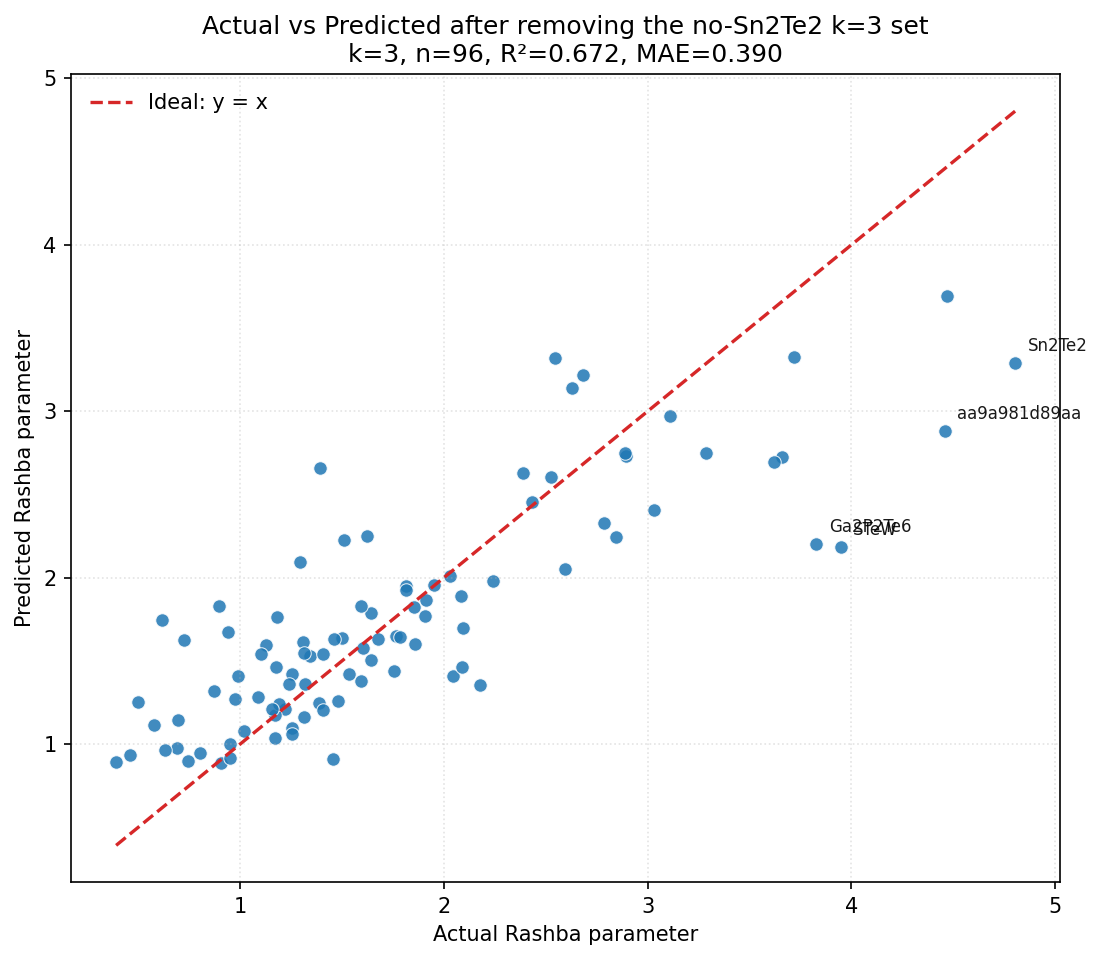

In [27]:
# Actual vs predicted plot for the best R2 removal case
# k = 3: use the existing no-Sn2Te2 candidate order, then evaluate the remaining compounds.

import matplotlib.pyplot as plt

BEST_K = 3
removed_uids = candidates_to_remove_in_order[:BEST_K]
removed_rows = df_99[df_99['uid'].isin(removed_uids)][['uid', 'Formula', TARGET]].copy()
removed_formulas = removed_rows['Formula'].tolist()

keep_mask = ~df_99['uid'].isin(removed_uids)
df_keep = df_99[keep_mask].reset_index(drop=True)
y_keep = df_keep[TARGET].values

y_pred_best, r2_best, mae_best = loo_preds(BASELINE, df_keep, y_keep)

plot_df = df_keep[['uid', 'Formula', TARGET]].copy()
plot_df['material'] = plot_df['Formula'].where(plot_df['Formula'].fillna('').astype(str).str.strip().ne(''), plot_df['uid'])
plot_df['y_pred'] = y_pred_best
plot_df['residual'] = plot_df[TARGET] - plot_df['y_pred']
plot_df['abs_error'] = plot_df['residual'].abs()

print(f'Best removal case: k={BEST_K}, n_remaining={len(df_keep)}, R2={r2_best:.6f}, MAE={mae_best:.6f}')
print(f'Removed uids: {", ".join(removed_uids)}')
print(f'Removed formulas: {", ".join(removed_formulas)}')

fig, ax = plt.subplots(figsize=(7.5, 6.5), dpi=150)
ax.scatter(plot_df[TARGET], plot_df['y_pred'], s=42, alpha=0.85, color='#1f77b4', edgecolor='white', linewidth=0.5)

min_val = min(plot_df[TARGET].min(), plot_df['y_pred'].min())
max_val = max(plot_df[TARGET].max(), plot_df['y_pred'].max())
ax.plot([min_val, max_val], [min_val, max_val], '--', color='#d62728', linewidth=1.6, label='Ideal: y = x')

# Label the high-error materials directly on the plot.
label_df = plot_df[plot_df['abs_error'] > 1.5].sort_values('abs_error', ascending=False)
if label_df.empty:
    label_df = plot_df.nlargest(5, 'abs_error')

for _, row in label_df.iterrows():
    ax.annotate(
        row['material'],
        (row[TARGET], row['y_pred']),
        textcoords='offset points',
        xytext=(6, 6),
        fontsize=8,
        alpha=0.9,
    )

ax.set_xlabel('Actual Rashba parameter')
ax.set_ylabel('Predicted Rashba parameter')
ax.set_title(
    'Actual vs Predicted after removing the no-Sn2Te2 k=3 set\n'
    f'k={BEST_K}, n={len(df_keep)}, R²={r2_best:.3f}, MAE={mae_best:.3f}'
)
ax.grid(True, linestyle=':', alpha=0.35)
ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

plot_df.to_csv(os.path.join(RESULTS_DIR, 'actual_vs_pred_best_r2_k3.csv'), index=False)


In [25]:
# High-error materials for the best k=3 removal case
# Show all compounds with absolute error > 1.5; if none qualify, fall back to the top 5.

removed_uids = candidates_to_remove_in_order[:3]
df_keep = df_99[~df_99['uid'].isin(removed_uids)].reset_index(drop=True)
y_keep = df_keep[TARGET].values

y_pred_best, r2_best, mae_best = loo_preds(BASELINE, df_keep, y_keep)
error_df = df_keep[['uid', 'Formula', TARGET]].copy()
error_df['material'] = error_df['Formula'].where(error_df['Formula'].fillna('').astype(str).str.strip().ne(''), error_df['uid'])
error_df['y_pred'] = y_pred_best
error_df['abs_error'] = (error_df[TARGET] - error_df['y_pred']).abs()

high_error_df = error_df[error_df['abs_error'] > 1.5].sort_values('abs_error', ascending=False)
report_df = high_error_df if not high_error_df.empty else error_df.nlargest(5, 'abs_error')

print(f'Best k=3 case: R2={r2_best:.6f}, MAE={mae_best:.6f}, n_remaining={len(df_keep)}')
if not high_error_df.empty:
    print('Materials with abs error > 1.5:')
else:
    print('No materials exceeded abs error > 1.5; showing top 5 by abs error instead:')

print(report_df[['material', 'uid', 'abs_error']].to_string(index=False))


Best k=3 case: R2=0.671769, MAE=0.390143, n_remaining=96
Materials with abs error > 1.5:
    material          uid  abs_error
        STeW 75ee10091f43   1.762520
    Ga2P2Te6 4cb4ea247ef4   1.626973
aa9a981d89aa aa9a981d89aa   1.577705
      Sn2Te2 03bcf7dcdaf2   1.515051


Running LOO on full 99-compound set...
Subset with Rashba < 3: n=87 compounds (out of 99)
Rashba range in subset: [0.393, 2.895]

LOO trained on all 99, evaluated on Rashba<3 subset: R2=0.467107, MAE=0.350582

Top 10 compounds by absolute error (within subset):
material          uid  Rashba_parameter   y_pred  abs_error
   SeTeW 6e2a4c6f4f57             1.394 2.609437   1.215437
  BiBrSe de5756e4fbfa             2.784 1.620650   1.163350
    HgTe 1a3bdd1b142a             0.618 1.757961   1.139961
 Bi2P2S6 287dcf4f1a19             1.406 2.439306   1.033306
   BiITe a84d988e38ac             0.467 1.441895   0.974895
    GeSe 211bcb7f05d6             0.940 1.855576   0.915576
   AsISe 5d829e480507             1.626 2.428610   0.802610
  BiClTe badda86cab42             1.458 0.677000   0.781000
TiHf3Te8 1667d1443160             1.512 2.278903   0.766903
    PbTe 3bc08d486d65             2.180 1.421397   0.758603



Running LOO on full 99-compound set...
Subset with Rashba < 3: n=87 compounds (out of 99)
Rashba range in subset: [0.393, 2.895]

LOO trained on all 99, evaluated on Rashba<3 subset: R2=0.467107, MAE=0.350582

Top 10 compounds by absolute error (within subset):
material          uid  Rashba_parameter   y_pred  abs_error
   SeTeW 6e2a4c6f4f57             1.394 2.609437   1.215437
  BiBrSe de5756e4fbfa             2.784 1.620650   1.163350
    HgTe 1a3bdd1b142a             0.618 1.757961   1.139961
 Bi2P2S6 287dcf4f1a19             1.406 2.439306   1.033306
   BiITe a84d988e38ac             0.467 1.441895   0.974895
    GeSe 211bcb7f05d6             0.940 1.855576   0.915576
   AsISe 5d829e480507             1.626 2.428610   0.802610
  BiClTe badda86cab42             1.458 0.677000   0.781000
TiHf3Te8 1667d1443160             1.512 2.278903   0.766903
    PbTe 3bc08d486d65             2.180 1.421397   0.758603



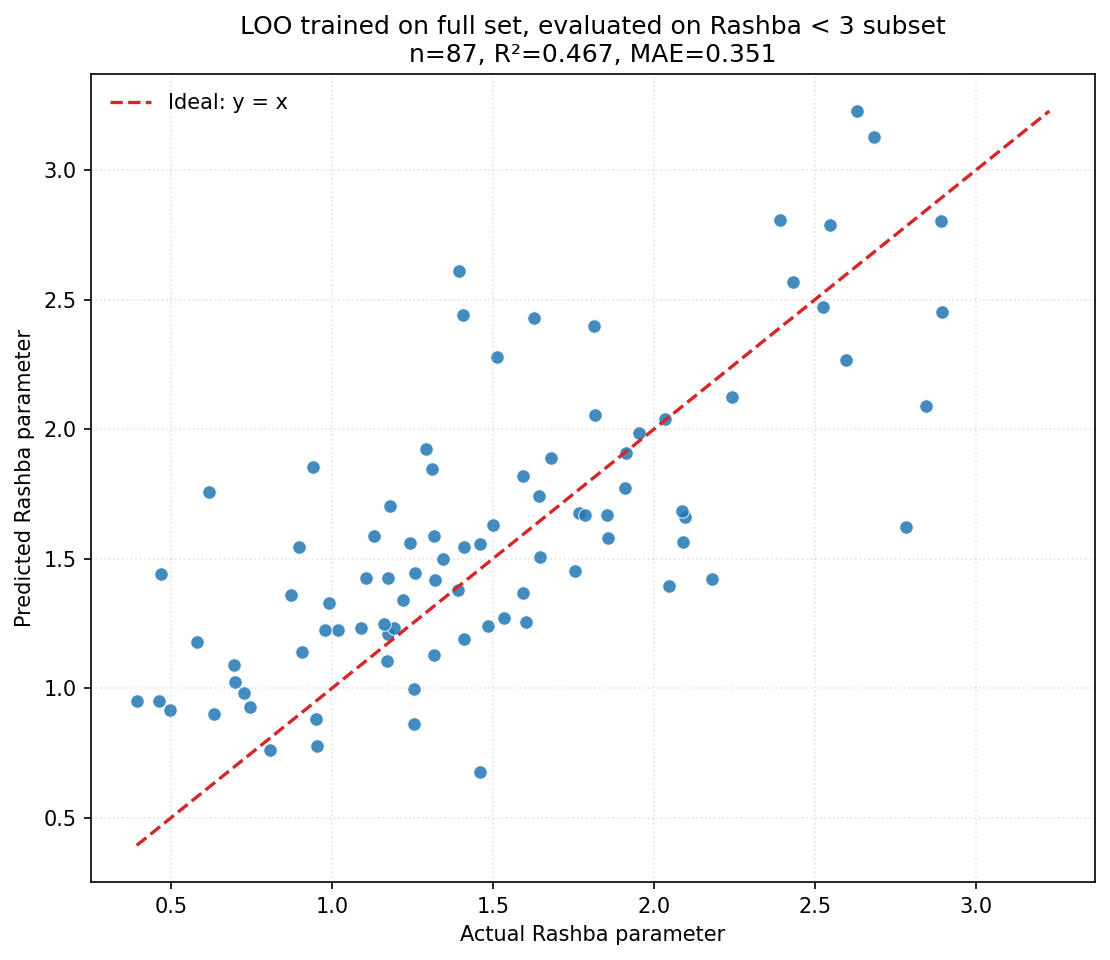